<a href="https://colab.research.google.com/github/maxkleiner/maXbox5/blob/main/machinelearningsteps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machinelearning Steps

This article will provide the clear cut understanding of Iris dataset and how to do classification (supervised learning) on Iris flowers dataset using python, seaborn and sklearn.


The Iris dataset is often used in machine learning and data science courses, because it’s simple to understand and well-defined, yet interesting enough to present real challenges to new learners. This single code snippet will use Python with Python4Delphi to classify the Iris dataset into one of three flower species: Setosa, Versicolor, or Virginica.

Download 1452_machinelearningsteps2python12plotdataset.pas (maXbox5)
[machinelearningsteps](https://sourceforge.net/projects/maxbox5/files/examples/1452_machinelearningsteps2python12plotdataset.pas/download)


The iris data consisted of 150 samples of three species of Iris. The first column represented sepal length, the second column represented sepal width, the third column represented petal length, and the fourth column represented petal width. I’m going to use sci-kit-learn to classify these instances according to their species.
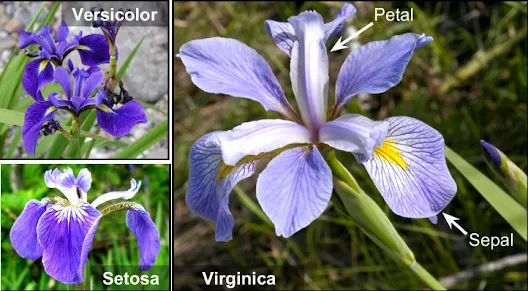

The provided Delphi and Python code snippet uses the Python4Delphi library, specifically the TPythonEngine component, to embed Python code execution into a Delphi application. It creates an instance of TPythonEngine and uses it to run a sequence of Python commands that implement a machine learning workflow with the iris dataset using popular Python libraries like pandas, matplotlib, pyplot, scikit-learn (sklearn), and seaborn.


# Import Libraries
First we load the libraries:

Before diving in, ensure as prerequisites you have these libraries installed:

In [189]:
pip install pandas numpy matplotlib seaborn scipy scikit-learn statsmodels

It executes multiple Python import statements to load common data science and machine learning libraries:
pandas (for data manipulation), matplotlib.pyplot (plotting),
sklearn’s modules including train_test_split,
RandomForestClassifier, for supervised learning
dataset loaders, and metrics like accuracy_score and confusion_matrix and It loads the iris dataset from sklearn.datasets and converts it into a pandas DataFrame.

In [190]:
import argparse

import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# matplotlib.use("TkAgg")

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import datasets
from sklearn.metrics import accuracy_score, confusion_matrix

# Load Dataset
But the data are not well structured for us to understand. So we need to convert it into a pandas DataFrame. Pandas is a great tool for doing all sorts of things related to datasets, including preprocessing and exploring them.

It loads the iris dataset from sklearn.datasets and converts it into a pandas DataFrame.
The data is split into training and test sets with stratification and fixed random seed as random_state for reproducibility and comparision.

In [191]:
iris = datasets.load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Explore Dataset
The dataset contains 150 samples of iris flowers, divided into three species: Setosa, Versicolor, and Virginica. Each sample is described by four features measured in centimeters:
*   Sepal Length: The length of the flower’s sepal.
*   Sepal Width: The width of the flower’s sepal.
*   Petal Length: The length of the flower’s petal.
*   Petal Width: The width of the flower’s petal.



In [192]:
irisd = datasets.load_iris()
irisdf = pd.DataFrame(
        data= np.c_[irisd['data'],irisd['target']],
        columns= irisd['feature_names']+['target']
        )
species = []
for i in range(len(irisd['target'])):
   if irisd['target'][i] == 0:
     species.append('setosa')
   elif irisd['target'][i] == 1:
     species.append('versicolor')
   else:
     species.append('virginica')
irisdf['species'] = species

Now we can print out a scatter plot:

species
setosa        50
versicolor    50
virginica     50
dtype: int64


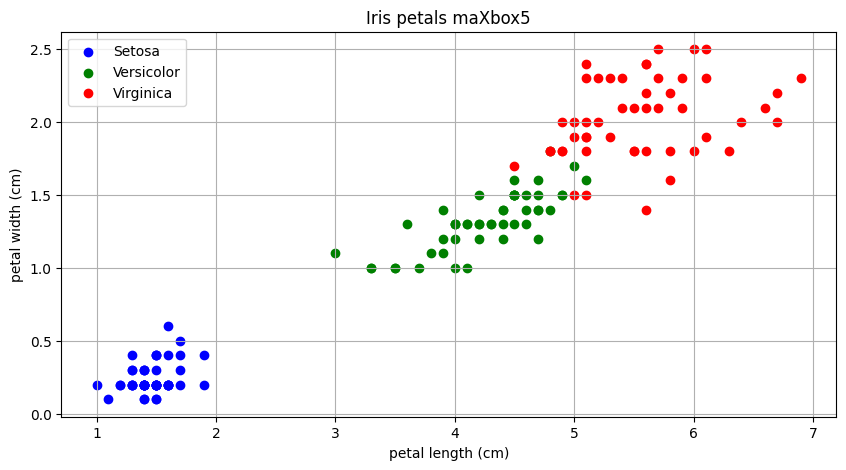

In [193]:
print(irisdf.groupby('species').size())
setosa = irisdf[irisdf.species =='setosa']
versicolor = irisdf[irisdf.species =='versicolor']
virginica = irisdf[irisdf.species =="virginica"]
fig, ax = plt.subplots()
fig.set_size_inches(10, 5) # adjusting the length and width of plot
# lables and scatter points
ax.scatter(setosa["petal length (cm)"],setosa["petal width (cm)"], label="Setosa",facecolor="blue")
ax.scatter(versicolor["petal length (cm)"],versicolor["petal width (cm)"],label="Versicolor",facecolor="green")
ax.scatter(virginica["petal length (cm)"],virginica["petal width (cm)"],label="Virginica",facecolor="red")
ax.set_xlabel("petal length (cm)")
ax.set_ylabel("petal width (cm)")
ax.grid()
ax.set_title("Iris petals maXbox5")
ax.legend()
plt.show()

# Classify the species
So we don’t need to hardcode the algorithm for classification since there are already many algorithms available in the sci-kit learn package. We can simply choose any of them and use them. Here, I am going to use the Random Forest Classifier model. Now, after training our model on training data, we can predict petal and sepal measurements on testing data as the features. And that’s the non binary cassification for the first block!

In [194]:
X_train,X_test, y_train,y_test = train_test_split(df[iris.feature_names],
iris.target,test_size=0.5, stratify=iris.target, random_state=123456)
rf = RandomForestClassifier(n_estimators=100, oob_score=True,random_state=123456)
rf.fit(X_train, y_train)
print('Classify accuracy: ',accuracy_score(y_test, rf.predict(X_test)))

Classify accuracy:  0.9333333333333333


Also, we can use the train_test_split function in sklearn in order to split the dataset into train and test.

We get Classify accuracy= 0.9333333333333333

Press enter or click to view image in full size


# Plotting the Performance Measures
Performance measures are used to evaluate effectiveness of classifiers on different datasets with different characteristics. For classification problems, there are three main measures for evaluating the model, the Precision (the accuracy of positive predictions or the number of most relevant values from retrieved values.), Recall (ratio of positive instances that are truly detected by the classifier), and confusion matrix.

In other words if you don’t recognize a person or a flower then its bad recall and if you recognize a person for another (confuse with) then its bad precision!

Precision, Recall, Confusion matrix, in testing

              precision    recall  f1-score   support

           0      1.000     1.000     1.000        25
           1      0.833     1.000     0.909        25
           2      1.000     0.800     0.889        25

    accuracy                          0.933        75
   macro avg      0.944     0.933     0.933        75
weighted avg      0.944     0.933     0.933        75



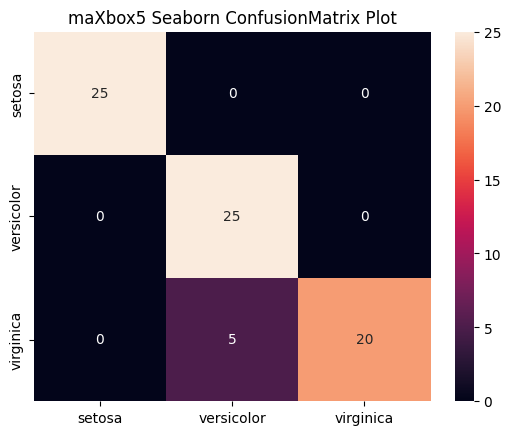

In [195]:
from sklearn import metrics
print("Precision, Recall, Confusion matrix, in testing\n")
print(metrics.classification_report(y_test, rf.predict(X_test), digits=3))
#https://www.blopig.com/blog/2017/07/using-random-forests-in-python-with-scikit-learn/
import seaborn as sns
cm = pd.DataFrame(confusion_matrix(y_test, rf.predict(X_test)),
                   columns=iris.target_names, index=iris.target_names)
sns.heatmap(cm, annot=True)
plt.title("maXbox5 Seaborn ConfusionMatrix Plot")
#plt.savefig("confusion_matrix1452.png")'+lf+
plt.show();

The scores are pretty good in this case only 5 misclassified. The main usage of the confusion matrix is to identify how many of the classes are misclassified by the classifier (false-positive or false-negative).
We check the recall of virginica (2) its 80%, that means only 80% are recognized (recall) as virginica so 20% are misclassified as versicolor!

On the other side the precision of versicolor (1) is only 83% because 5 from virginica are misclassified as versicolor and that means 25/30= 0.8333 or 83% precision!

# Conclusion
It executes multiple Python import statements to load common data science and machine learning libraries: pandas (for data manipulation), matplotlib.pyplot (plotting), sklearn’s modules including train_test_split, RandomForestClassifier, dataset loaders, and metrics like accuracy_score and confusion_matrix and It loads the iris dataset from sklearn.datasets and converts it into a pandas DataFrame.

The data is split into training and test sets with stratification and fixed random seed for reproducibility.
A RandomForestClassifier model is created and trained on the training dataset.

The accuracy of the model on the test set is evaluated and printed using the Python accuracy_score function and a confusion matrix is generated, converted into a pandas DataFrame, and plotted using seaborn’s heatmap with an annotated matrix plot.
The plot is finalized with a title and displayed using matplotlib and seaborn. Max Kleiner, Nov. 2025